Tools Used

- Python
- Pandas
- Seaborn
- Matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("crime.csv")
df.head()

,MajorText,MinorText,BoroughName,202403,202404,202405,202406,202407,202408,202409,...,202505,202506,202507,202508,202509,202510,202511,202512,202601,202602
0,ARSON AND CRIMINAL DAMAGE,ARSON,Barking and Dagenham,6,3,8,2,3,10,9,...,10,10,12,10,5,6,8,7,0,3
1,ARSON AND CRIMINAL DAMAGE,CRIMINAL DAMAGE,Barking and Dagenham,134,112,102,106,131,114,80,...,108,124,136,126,100,100,106,125,101,98
2,BURGLARY,BURGLARY BUSINESS AND COMMUNITY,Barking and Dagenham,30,24,28,33,21,26,31,...,28,25,24,23,23,16,22,23,26,29
3,BURGLARY,RES BURGLARY OF A HOME,Barking and Dagenham,45,42,30,31,28,34,31,...,31,35,31,29,31,33,64,52,47,40
4,BURGLARY,RES BURGLARY OF UNCONNECTED BUILDING,Barking and Dagenham,5,10,11,6,8,12,18,...,7,16,5,13,12,22,15,23,6,17


In [3]:
print(df.columns)

Index(['MajorText', 'MinorText', 'BoroughName', '202403', '202404', '202405',
       '202406', '202407', '202408', '202409', '202410', '202411', '202412',
       '202501', '202502', '202503', '202504', '202505', '202506', '202507',
       '202508', '202509', '202510', '202511', '202512', '202601', '202602'],
      dtype='object')


In [4]:
month_cols = df.columns[3:]
month_cols

Index(['202403', '202404', '202405', '202406', '202407', '202408', '202409',
       '202410', '202411', '202412', '202501', '202502', '202503', '202504',
       '202505', '202506', '202507', '202508', '202509', '202510', '202511',
       '202512', '202601', '202602'],
      dtype='object')

In [5]:
crime_long = df.melt(
    id_vars=["MajorText","MinorText","BoroughName"],
    value_vars=month_cols,
    var_name="Month",
    value_name="CrimeCount"
)

crime_long.head()

,MajorText,MinorText,BoroughName,Month,CrimeCount
0,ARSON AND CRIMINAL DAMAGE,ARSON,Barking and Dagenham,202403,6
1,ARSON AND CRIMINAL DAMAGE,CRIMINAL DAMAGE,Barking and Dagenham,202403,134
2,BURGLARY,BURGLARY BUSINESS AND COMMUNITY,Barking and Dagenham,202403,30
3,BURGLARY,RES BURGLARY OF A HOME,Barking and Dagenham,202403,45
4,BURGLARY,RES BURGLARY OF UNCONNECTED BUILDING,Barking and Dagenham,202403,5


In [6]:
crime_long["Month"] = pd.to_datetime(crime_long["Month"], format="%Y%m")

In [7]:
crime_long.head()

,MajorText,MinorText,BoroughName,Month,CrimeCount
0,ARSON AND CRIMINAL DAMAGE,ARSON,Barking and Dagenham,2024-03-01,6
1,ARSON AND CRIMINAL DAMAGE,CRIMINAL DAMAGE,Barking and Dagenham,2024-03-01,134
2,BURGLARY,BURGLARY BUSINESS AND COMMUNITY,Barking and Dagenham,2024-03-01,30
3,BURGLARY,RES BURGLARY OF A HOME,Barking and Dagenham,2024-03-01,45
4,BURGLARY,RES BURGLARY OF UNCONNECTED BUILDING,Barking and Dagenham,2024-03-01,5


In [8]:
monthly_crime = crime_long.groupby("Month")["CrimeCount"].sum().reset_index()

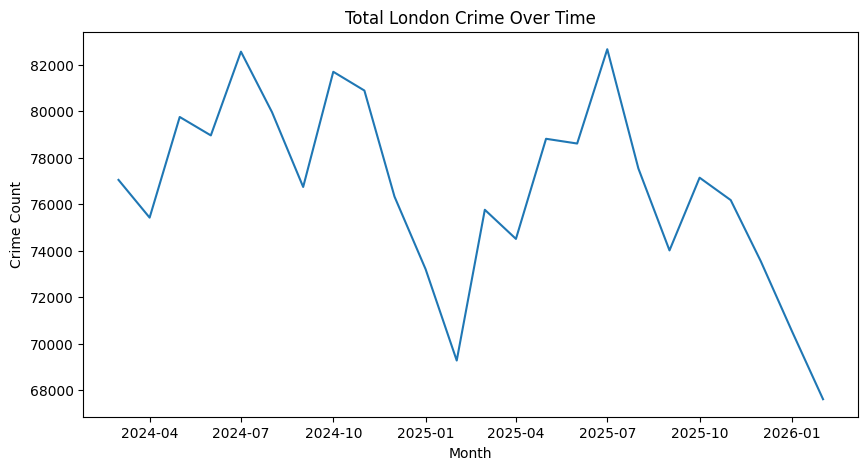

In [9]:
plt.figure(figsize=(10,5))

sns.lineplot(data=monthly_crime, x="Month", y="CrimeCount")

plt.title("Total London Crime Over Time")
plt.xlabel("Month")
plt.ylabel("Crime Count")

plt.show()

# Total Crime Over Time

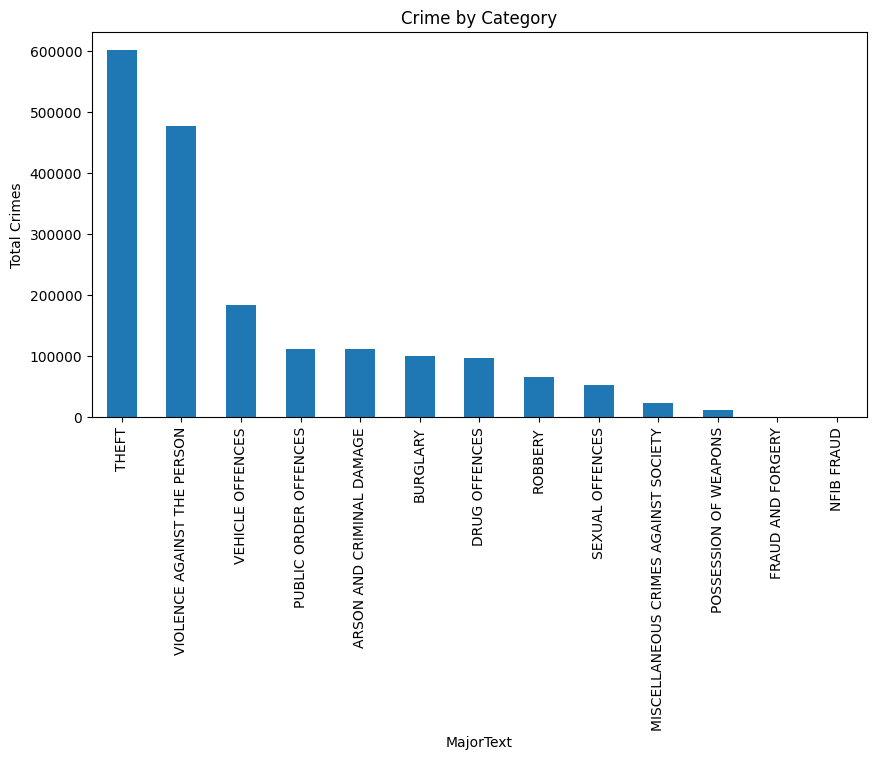

In [10]:
crime_type = crime_long.groupby("MajorText")["CrimeCount"].sum().sort_values(ascending=False)
crime_type

crime_type.plot(kind="bar", figsize=(10,5))

plt.title("Crime by Category")
plt.ylabel("Total Crimes")

plt.show()

# Crime by Category

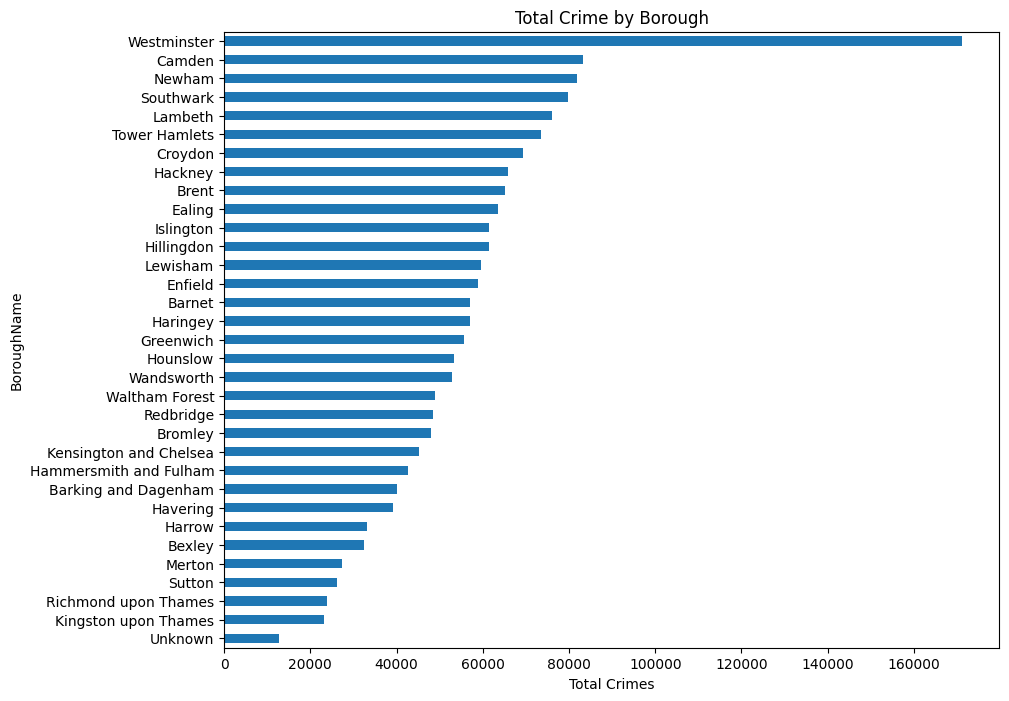

In [11]:
borough_crime = crime_long.groupby("BoroughName")["CrimeCount"].sum().sort_values()
borough_crime

borough_crime.plot(kind="barh", figsize=(10,8))

plt.title("Total Crime by Borough")
plt.xlabel("Total Crimes")

plt.show()

# Crime Hotspots by Borough

In [12]:
borough_crime.sort_values(ascending=False).head(10)

# Top 10 Crime Hotspots

,CrimeCount
BoroughName,
Westminster,171162
Camden,83218
Newham,81756
Southwark,79856
Lambeth,76165
Tower Hamlets,73421
Croydon,69314
Hackney,65937
Brent,65148


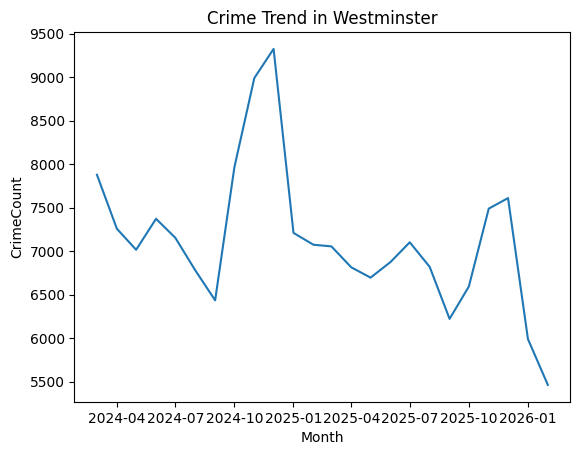

In [13]:
westminster = crime_long[crime_long["BoroughName"]=="Westminster"]

westminster_monthly = westminster.groupby("Month")["CrimeCount"].sum().reset_index()

sns.lineplot(data=westminster_monthly, x="Month", y="CrimeCount")

plt.title("Crime Trend in Westminster")

plt.show()

# Westminister Crime Trend